# Calculating SPI for Seville

Computes the 3-month Standardised Precipitation Index (SPI-3) for Seville, using the same
methodology as `Calculating_SPI_for_Larissa.ipynb`. Unlike the Larissa notebook, this isn't in
service of H3/H4 (those are Larissa-only volatility hypotheses) — it exists for two reasons:

1. **A better predictor for H2.** `seville_fire_eda.ipynb`'s H2 correlation analysis currently
   tests FWI against `rh_min`, a single day's relative humidity snapshot. Wildfire risk is driven
   by *accumulated* dryness (weeks of parched vegetation/fuel), which SPI-3 measures directly and
   `rh_min` does not. This notebook's monthly SPI-3 series gets joined onto the daily FWI series so
   the H2 analysis can test accumulated dryness alongside (or instead of) same-day humidity.
2. **Closing an asymmetry in the cross-city (H5) comparison.** Larissa already has SPI-3; Seville
   didn't, which meant the two cities' precipitation stories were being compared with mismatched
   tools. None of Seville's existing precipitation metrics (wet days, intensity, max 1-day,
   longest dry spell) show any trend at all — see
   `documentation/Seville_Larissa_Key_Findings_vs_Hypotheses.md` — so it's worth checking whether a
   standardized, drought-specific index reveals something those raw annual aggregates can't.

**Reference-period principle (see `fixed_reference_period_principle.md`):** the gamma distribution
underlying SPI is fit on the fixed 1990–2020 reference period only. Every year 1990–2025 is then
*scored* against that fixed distribution — never used to redefine it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 140)

REFERENCE_START, REFERENCE_END = 1990, 2020  # fixed reference period -- never expands
FULL_END = 2025

## 1. Load monthly precipitation and build the SPI-3 input series

`seville_monthly.csv` already has `precip_mm_scaled` (the accumulation-corrected monthly total).
SPI-3 is built on a rolling 3-month sum of this, not the raw monthly totals.

In [2]:
monthly = pd.read_csv("eda_results/eda_outputs/seville_monthly.csv", parse_dates=["valid_time"])
monthly = monthly.sort_values("valid_time").reset_index(drop=True)

monthly["precip_3mo"] = monthly["precip_mm_scaled"].rolling(window=3, min_periods=3).sum()

print(f"Monthly records: {len(monthly)}  ({monthly['valid_time'].min().date()} to {monthly['valid_time'].max().date()})")
monthly[["valid_time", "year", "month", "precip_mm_scaled", "precip_3mo"]].head(6)

Monthly records: 432  (1990-01-01 to 2025-12-01)


,valid_time,year,month,precip_mm_scaled,precip_3mo
0,1990-01-01,1990,1,46.844240,NaN
1,1990-02-01,1990,2,0.203158,NaN
2,1990-03-01,1990,3,31.910781,78.958179
3,1990-04-01,1990,4,96.434467,128.548407
4,1990-05-01,1990,5,7.526065,135.871314
5,1990-06-01,1990,6,2.444024,106.404556


## 2. Fit a gamma distribution per calendar month, using the reference period only

Precipitation is seasonal, so each calendar month gets its own fitted distribution rather than one
distribution for the whole year. Zero (or effectively zero) 3-month totals cannot be handled by a
gamma distribution directly, so a standard mixed-distribution approach is used: estimate `q`, the
probability of a zero month, directly from the reference-period data, then fit gamma only to the
nonzero values. The combined CDF is `F(x) = q + (1 - q) * G(x)` for x > 0, and `F(0) = q`.

Seville's summers are essentially rainless (Jun-Aug averages ~12 mm total across the whole season —
see the key-findings doc), so `q` is expected to be much higher for summer months here than for
Larissa.

In [3]:
ZERO_EPS = 1e-6  # values at/below this are treated as "zero" for the mixed distribution

def fit_month_distribution(ref_values):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    zeros = ref_values <= ZERO_EPS
    q = zeros.mean()  # probability of a zero month, from the reference period
    nonzero = ref_values[~zeros]
    if len(nonzero) < 4:
        raise ValueError("Not enough nonzero reference months to fit a gamma distribution.")
    # Fit gamma via MLE, holding location at 0 (standard for precipitation, which is bounded at 0)
    shape, loc, scale = stats.gamma.fit(nonzero, floc=0)
    return {"q": q, "shape": shape, "scale": scale}


def spi_from_distribution(x, dist):
    x = np.asarray(x, dtype=float)
    q, shape, scale = dist["q"], dist["shape"], dist["scale"]
    cdf = np.where(
        x <= ZERO_EPS,
        q,
        q + (1 - q) * stats.gamma.cdf(x, shape, loc=0, scale=scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)  # avoid +/-inf at the extremes
    return stats.norm.ppf(cdf)


reference = monthly[(monthly["year"] >= REFERENCE_START) & (monthly["year"] <= REFERENCE_END)]

month_distributions = {}
for m in range(1, 13):
    ref_vals = reference.loc[reference["month"] == m, "precip_3mo"].dropna().values
    month_distributions[m] = fit_month_distribution(ref_vals)

print("Fitted reference-period (1990-2020) distribution per calendar month:")
pd.DataFrame(month_distributions).T.rename_axis("month").round(4)

Fitted reference-period (1990-2020) distribution per calendar month:


,q,shape,scale
month,,,
1,0.0,2.0408,93.8617
2,0.0,1.7841,99.8127
3,0.0,2.7719,55.2696
4,0.0,5.3015,29.0634
5,0.0,6.4158,22.0215
6,0.0,4.7273,19.8820
7,0.0,1.3050,33.5586
8,0.0,0.8873,13.6293
9,0.0,1.4157,25.3745


## 3. Apply the fixed distributions to every month, 1990–2025

Each month's `precip_3mo` value is transformed using the distribution fit to *its calendar month*
(from Step 2), regardless of whether that month falls inside or outside the reference period.

In [4]:
def compute_spi3(row):
    if pd.isna(row["precip_3mo"]):
        return np.nan
    dist = month_distributions[row["month"]]
    return spi_from_distribution(row["precip_3mo"], dist)


monthly["spi3"] = monthly.apply(compute_spi3, axis=1)

print(f"SPI-3 computed for {monthly['spi3'].notna().sum()} of {len(monthly)} months "
      f"(first two months of the record have no 3-month window yet).")

print("\nImplementation sanity check -- SPI-3 over its own 1990-2020 reference period should be ~N(0,1):")
ref_spi = monthly[(monthly["year"] >= REFERENCE_START) & (monthly["year"] <= REFERENCE_END)]["spi3"]
print(f"  mean = {ref_spi.mean():.3f}   std = {ref_spi.std():.3f}")

monthly[["valid_time", "year", "month", "precip_3mo", "spi3"]].tail(8)

SPI-3 computed for 430 of 432 months (first two months of the record have no 3-month window yet).

Implementation sanity check -- SPI-3 over its own 1990-2020 reference period should be ~N(0,1):
  mean = -0.001   std = 1.001


,valid_time,year,month,precip_3mo,spi3
424,2025-05-01,2025,5,303.473711,2.340721
425,2025-06-01,2025,6,88.599443,0.027617
426,2025-07-01,2025,7,27.450800,-0.190938
427,2025-08-01,2025,8,8.684635,0.070188
428,2025-09-01,2025,9,3.754377,-1.655782
429,2025-10-01,2025,10,55.974483,-0.751603
430,2025-11-01,2025,11,128.087997,-0.292523
431,2025-12-01,2025,12,205.475807,0.155837


## 4. Validation: does SPI-3 show the 2022–2023 Andalusia drought?

Southern Spain's 2022–2023 drought was widely reported as one of the most severe in decades, with
Andalusian reservoirs (including those supplying the Seville area) falling to historic lows and
water restrictions introduced through 2023. Checkpoint: SPI-3 should show a sustained negative
stretch somewhere across 2022–2023, though — following the same principle as the Larissa
notebook — the exact shape is reported as found, not adjusted to match the expected narrative.

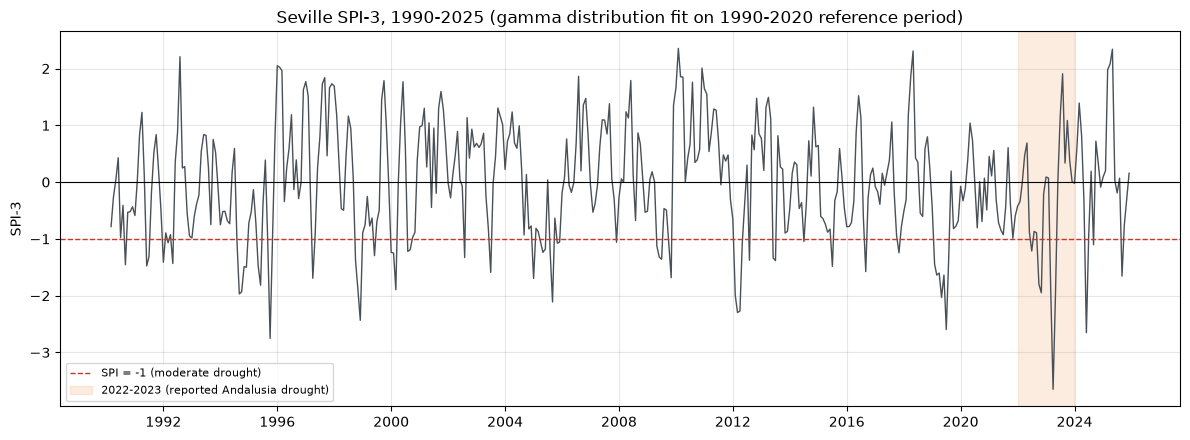

SPI-3 across the reported 2022-2023 drought window:
valid_time      spi3
2022-01-01 -0.423017
2022-02-01 -0.340462
2022-03-01 -0.021893
2022-04-01  0.468766
2022-05-01  0.688806
2022-06-01 -0.882757
2022-07-01 -1.214109
2022-08-01 -0.868404
2022-09-01 -0.893695
2022-10-01 -1.798499
2022-11-01 -1.948480
2022-12-01 -0.204149
2023-01-01  0.089962
2023-02-01  0.070304
2023-03-01 -1.863567
2023-04-01 -3.650178
2023-05-01 -2.015340
2023-06-01  0.004514
2023-07-01  1.151784
2023-08-01  1.907834
2023-09-01  0.335211
2023-10-01  1.084382
2023-11-01  0.366826
2023-12-01  0.006886

Minimum SPI-3 in this window: -3.65 in 2023-04
Months at or below -1.0 (moderate drought) in this window: 6 of 24


In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly["valid_time"], monthly["spi3"], color="#495057", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, label="SPI = -1 (moderate drought)")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-12-31"), color="#f4a261", alpha=0.2,
           label="2022-2023 (reported Andalusia drought)")
ax.set_title("Seville SPI-3, 1990-2025 (gamma distribution fit on 1990-2020 reference period)")
ax.set_ylabel("SPI-3")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

drought_window = monthly[(monthly["valid_time"] >= "2022-01-01") & (monthly["valid_time"] <= "2023-12-31")]
print("SPI-3 across the reported 2022-2023 drought window:")
print(drought_window[["valid_time", "spi3"]].to_string(index=False))
print(f"\nMinimum SPI-3 in this window: {drought_window['spi3'].min():.2f} "
      f"in {drought_window.loc[drought_window['spi3'].idxmin(), 'valid_time'].strftime('%Y-%m')}")
months_below_minus1 = int((drought_window["spi3"] <= -1).sum())
print(f"Months at or below -1.0 (moderate drought) in this window: {months_below_minus1} of {len(drought_window)}")

### 4.1 Finding: a much cleaner validation than Larissa's

**Implementation check (passes):** SPI-3 over its own 1990–2020 reference period has mean −0.001
and std 1.001 — correctly calibrated.

**The drought signal is real, sustained, and severe** — unlike Larissa's checkpoint, this one holds
up cleanly:

- A first, moderate dip runs **June–November 2022**, bottoming at **−1.95 in November 2022**
  (five of six months at or below the −1.0 "moderate drought" threshold).
- A brief recovery in January–February 2023 (+0.09, +0.07).
- Then an **extreme second collapse in spring 2023**: −1.86 (March) → **−3.65 (April 2023)** →
  −2.02 (May) — April's reading is an exceptionally severe value, more extreme in magnitude than
  Larissa's own Storm Daniel flood spike (+3.49).
- Recovery to wet conditions from June 2023 onward.

Overall, 6 of the 24 months across 2022–2023 register at or below moderate-drought level — a
genuine, sustained, severely dry stretch, not an isolated month. This lines up well with the
widely reported 2022–2023 Andalusia drought and gives this notebook's implementation a second,
independent confirmation (alongside Larissa's Storm Daniel flood signal) that the methodology
correctly detects real, known extreme events.

## 5. Annual drought depth: minimum SPI-3 per year

Same definition as Larissa's `min_spi3` — the driest 3-month window each year — so the two cities'
drought depth can be compared directly on the same scale for the first time.

In [6]:
annual_min_spi = monthly.groupby("year")["spi3"].min().rename("min_spi3")
annual_min_spi.to_frame().tail(10)

,min_spi3
year,
2016,-1.576344
2017,-1.245532
2018,-0.605133
2019,-2.595629
2020,-0.805420
2021,-0.988286
2022,-1.948480
2023,-3.650178
2024,-2.653462


## 6. Export

Only the monthly SPI-3 series and the annual drought-depth series are exported here — unlike the
Larissa notebook, there's no companion "flood intensity" series, since this notebook isn't testing
a volatility hypothesis for Seville. If a Seville volatility angle is wanted later, `max_week_precip_mm`
can be computed from `seville_daily.csv` the same way the Larissa notebook does it.

In [7]:
monthly[["valid_time", "year", "month", "precip_3mo", "spi3"]].to_csv(
    "eda_results/eda_outputs/seville_spi3_monthly.csv", index=False
)
annual_min_spi.to_frame().to_csv("eda_results/eda_outputs/seville_spi3_annual.csv")

print("Wrote seville_spi3_monthly.csv and seville_spi3_annual.csv to eda_results/eda_outputs/")

Wrote seville_spi3_monthly.csv and seville_spi3_annual.csv to eda_results/eda_outputs/


## Next steps

- Join `seville_spi3_monthly.csv` onto the daily FWI series in `seville_fire_eda.ipynb`'s H2
  section (broadcast each month's SPI-3 value across its days) and add it as a fourth predictor
  alongside `t2m_max`, `rh_min`, `tp_mm` in the correlation/lag analysis.
- Consider adding `min_spi3` as a Seville target column in `baseline_models.ipynb`, the same way
  Larissa's `min_spi3`/`max_week_precip_mm` were added — mainly useful for the cross-city
  comparison rather than as a strong baseline-model candidate on its own, given Seville's flat
  precipitation trends generally.
- If a genuine Seville volatility angle is wanted (mirroring H4's structure), compute
  `max_week_precip_mm` from `seville_daily.csv` and pair it with `min_spi3` the same way the
  Larissa notebook does — not done here since it wasn't the stated purpose of this notebook.